In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

# Where should Lawton retire?

In [2]:
income = Table.read_table('data/us-median-income-2023.csv')
income

Geographic Area Name,Median income estimate
Alabama,33108
Alaska,43069
Arizona,39900
Arkansas,32294
California,41901
Colorado,46958
Connecticut,46415
Delaware,41678
District of Columbia,70144
Florida,36270


In [3]:
income.show(60)

Geographic Area Name,Median income estimate
Alabama,33108
Alaska,43069
Arizona,39900
Arkansas,32294
California,41901
Colorado,46958
Connecticut,46415
Delaware,41678
District of Columbia,70144
Florida,36270


In [4]:
income = income.take(np.arange(52, income.num_rows))
income

Geographic Area Name,Median income estimate
"Abanda CDP, Alabama",34911
"Abbeville city, Alabama",21678
"Adamsville city, Alabama",31873
"Addison town, Alabama",30833
"Akron town, Alabama",22500
"Alabaster city, Alabama",43502
"Albertville city, Alabama",29150
"Alexander City city, Alabama",27114
"Alexandria CDP, Alabama",41685
"Aliceville city, Alabama",18750


In [5]:
income.where(0, are.containing('Fresno'))

Geographic Area Name,Median income estimate
"Centerville CDP (Fresno County), California",-
"Fresno city, California",33148
"Fresno CDP, Ohio",16488
"Fresno CDP, Texas",42540
"Los Fresnos city, Texas",33168
"Los Fresnos CDP, Texas",45057


In [6]:
income.where(0, are.containing('Clovis'))

Geographic Area Name,Median income estimate
"Clovis city, California",47696
"Clovis city, New Mexico",31392


In [7]:
def fix(x):
    try:
        return int(x)
    except:
        return -1

income = income.with_column('Median income estimate', income.apply(fix, 1))

In [8]:
income.where(0, are.containing('Fresno'))

Geographic Area Name,Median income estimate
"Centerville CDP (Fresno County), California",-1
"Fresno city, California",33148
"Fresno CDP, Ohio",16488
"Fresno CDP, Texas",42540
"Los Fresnos city, Texas",33168
"Los Fresnos CDP, Texas",45057


In [9]:
income.sort(1, descending=True)

Geographic Area Name,Median income estimate
"California Hot Springs CDP, California",211250
"Loma Mar CDP, California",207981
"Keswick CDP, Virginia",179257
"Indian Field CDP, Connecticut",174412
"Ratliff City town, Oklahoma",173016
"Oak Hills CDP, Iowa",171500
"Tuxedo Park village, New York",171389
"Blawenburg CDP, New Jersey",166250
"Solsberry CDP, Indiana",165202
"Barton Hills village, Michigan",160625


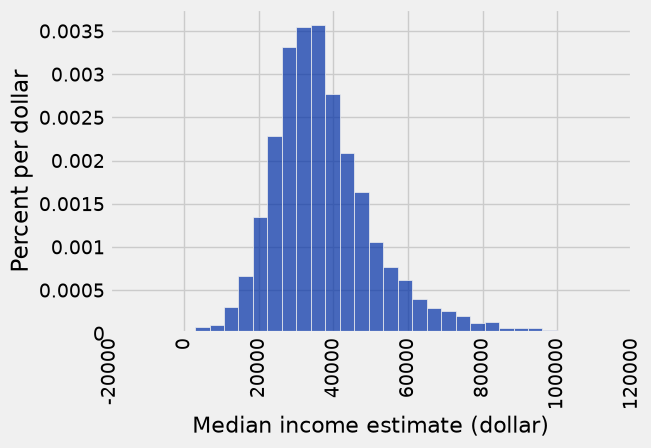

In [10]:
income.where(1, are.between_or_equal_to(0, 100000)).hist(1, bins=25, unit='dollar')

In [11]:
tjs = Table.read_table('data/trader-joes-locations-2025.csv')
tjs

City
"Birmingham, AL"
"Hoover, AL"
"Huntsville, AL"
"Chandler, AZ"
"Gilbert, AZ"
"Glendale, AZ"
"Mesa, AZ"
"Oro Valley, AZ"
"Phoenix, AZ"
"Prescott, AZ"


In [12]:
'Fresno, CA'.split(',')

['Fresno', ' CA']

In [13]:
'Fresno, CA'.split(',')[0]

'Fresno'

In [14]:
'Fresno, CA'.split(',')[1]

' CA'

In [15]:
'Fresno, CA'.split(',')[1].strip()

'CA'

In [16]:
def get_city(s):
    return s.split(',')[0]

def get_state_abbrev(s):
    return s.split(',')[1].strip()

In [17]:
get_city('Clovis, CA')

'Clovis'

In [18]:
get_state_abbrev('Clovis, CA')

'CA'

In [19]:
state_abbrevs = Table.read_table('data/state-abbreviations.csv')
state_abbrevs

Name,Abbreviation
Alabama,AL
Alaska,AK
American Samoa,AS
Arizona,AZ
Arkansas,AR
California,CA
Colorado,CO
Connecticut,CT
Delaware,DE
District of Columbia,DC


In [20]:
state_abbrevs.where('Abbreviation', 'CA').row(0).item(0)

'California'

In [21]:
def get_state(s):
    state_abbrev = get_state_abbrev(s)
    return state_abbrevs.where('Abbreviation', state_abbrev).row(0).item(0)

In [22]:
get_state('Clovis, CA')

'California'

In [23]:
tjs

City
"Birmingham, AL"
"Hoover, AL"
"Huntsville, AL"
"Chandler, AZ"
"Gilbert, AZ"
"Glendale, AZ"
"Mesa, AZ"
"Oro Valley, AZ"
"Phoenix, AZ"
"Prescott, AZ"


In [24]:
tjs = Table().with_columns(
    'City', tjs.apply(get_city, 'City'),
    'State', tjs.apply(get_state, 0)
)
tjs

City,State
Birmingham,Alabama
Hoover,Alabama
Huntsville,Alabama
Chandler,Arizona
Gilbert,Arizona
Glendale,Arizona
Mesa,Arizona
Oro Valley,Arizona
Phoenix,Arizona
Prescott,Arizona


In [25]:
income

Geographic Area Name,Median income estimate
"Abanda CDP, Alabama",34911
"Abbeville city, Alabama",21678
"Adamsville city, Alabama",31873
"Addison town, Alabama",30833
"Akron town, Alabama",22500
"Alabaster city, Alabama",43502
"Albertville city, Alabama",29150
"Alexander City city, Alabama",27114
"Alexandria CDP, Alabama",41685
"Aliceville city, Alabama",18750


In [26]:
income.where(0, are.containing('Phoenix'))

Geographic Area Name,Median income estimate
"Phoenix city, Arizona",40786
"Phoenix Lake CDP, California",40493
"Phoenix village, Illinois",24000
"Phoenix village, New York",37980
"Phoenix city, Oregon",30893
"Phoenixville borough, Pennsylvania",60073


In [27]:
income.where(0, are.containing('Phoenix')).where(0, are.containing('Arizona'))

Geographic Area Name,Median income estimate
"Phoenix city, Arizona",40786


In [28]:
tjs.show(30)

City,State
Birmingham,Alabama
Hoover,Alabama
Huntsville,Alabama
Chandler,Arizona
Gilbert,Arizona
Glendale,Arizona
Mesa,Arizona
Oro Valley,Arizona
Phoenix,Arizona
Prescott,Arizona


In [29]:
def get_median_income(city, state):
    results = income.where(0, are.containing(city)).where(0, are.containing(state))
    if results.num_rows > 0:
        return results.column(1).item(0)
    else:
        return -1

In [30]:
tjs_with_income = tjs.with_column('Median Income', tjs.apply(get_median_income, 'City', 'State'))
tjs_with_income

City,State,Median Income
Birmingham,Alabama,28054
Hoover,Alabama,53074
Huntsville,Alabama,38349
Chandler,Arizona,52580
Gilbert,Arizona,55389
Glendale,Arizona,36441
Mesa,Arizona,24573
Oro Valley,Arizona,50816
Phoenix,Arizona,40786
Prescott,Arizona,38235


In [31]:
tjs_with_income.sort('Median Income')

City,State,Median Income
Chatsworth,California,-1
Eagle Rock,California,-1
Encino,California,-1
Fresno,California,-1
Granada Hills,California,-1
Greenbrae,California,-1
La Canada,California,-1
La Jolla,California,-1
Marina Del Rey,California,-1
North Hollywood,California,-1


In [32]:
income.where(0, are.containing('Fresno')).where(0, are.containing('California'))

Geographic Area Name,Median income estimate
"Centerville CDP (Fresno County), California",-1
"Fresno city, California",33148


In [33]:
tjs_with_income.where('Median Income', are.above(0)).sort('Median Income').show(25)

City,State,Median Income
Fairfield,Connecticut,4383
State College,Pennsylvania,10085
East Lansing,Michigan,12408
Newark,Delaware,17087
College Park,Maryland,17695
Williamsburg,Virginia,23543
Mesa,Arizona,24573
Kalamazoo,Michigan,24899
Gainesville,Florida,25603
Corvallis,Oregon,26868


In [34]:
# The first two are "cities" containing only college students

# Mendel

In [35]:
mendel_proportions = make_array(0.75, 0.25)
mendel_proportions_purple = mendel_proportions.item(0)

In [36]:
sample_proportions(929, mendel_proportions)

array([ 0.75672766,  0.24327234])

In [37]:
abs(0.74811625 - mendel_proportions_purple)

0.0018837499999999618

In [38]:
def one_simulated_distance():
    sample_proportions_purple = sample_proportions(929, mendel_proportions).item(0)
    return abs(sample_proportions_purple - mendel_proportions_purple)

In [39]:
one_simulated_distance()

0.0169537136706136

In [40]:
observed_distance = (705 / 929) - 0.75
observed_distance

0.008880516684607098

In [41]:
repetitions = 1000
distances = make_array()
for i in np.arange(repetitions):
    distances = np.append(distances, one_simulated_distance())

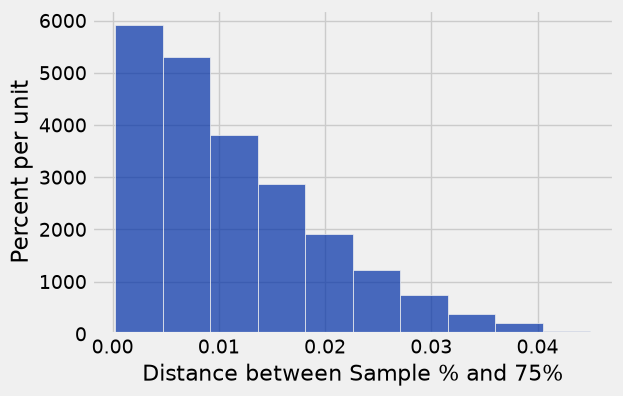

In [42]:
Table().with_column(
    'Distance between Sample % and 75%', distances
).hist()

In [43]:
np.count_nonzero(distances >= observed_distance) / repetitions

0.53100000000000003

In [44]:
# Conclusion: we do not reject the null

# Cereal

In [45]:
cereal = Table.read_table('data/cereal.csv')
cereal

name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
100% Bran,N,C,70,4,1,130,10,5,6,280,25,3,1,0.33,68.403
100% Natural Bran,Q,C,120,3,5,15,2,8,8,135,0,3,1,1,33.9837
All-Bran,K,C,70,4,1,260,9,7,5,320,25,3,1,0.33,59.4255
All-Bran with Extra Fiber,K,C,50,4,0,140,14,8,0,330,25,3,1,0.5,93.7049
Almond Delight,R,C,110,2,2,200,1,14,8,-1,25,3,1,0.75,34.3848
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1,0.75,29.5095
Apple Jacks,K,C,110,2,0,125,1,11,14,30,25,2,1,1,33.1741
Basic 4,G,C,130,3,2,210,2,18,8,100,25,3,1.33,0.75,37.0386
Bran Chex,R,C,90,2,1,200,4,15,6,125,25,1,1,0.67,49.1203
Bran Flakes,P,C,90,3,0,210,5,13,5,190,25,3,1,0.67,53.3138


In [46]:
cereal.select('shelf', 'sugars').group('shelf', np.average)

shelf,sugars average
1,4.8
2,9.61905
3,6.52778


In [47]:
cereal.with_column(
    'Shuffled Label', cereal.sample(with_replacement=False).column('shelf')
).where('Shuffled Label', 2).column('sugars').mean()

6.5714285714285712

In [48]:
def one_simulated_average():
    return cereal.with_column(
        'Shuffled Label', cereal.sample(with_replacement=False).column('shelf')
    ).where('Shuffled Label', 2).column('sugars').mean()

repetitions = 1000
simulated_averages = make_array()
for i in np.arange(repetitions):
    simulated_averages = np.append(simulated_averages, one_simulated_average())

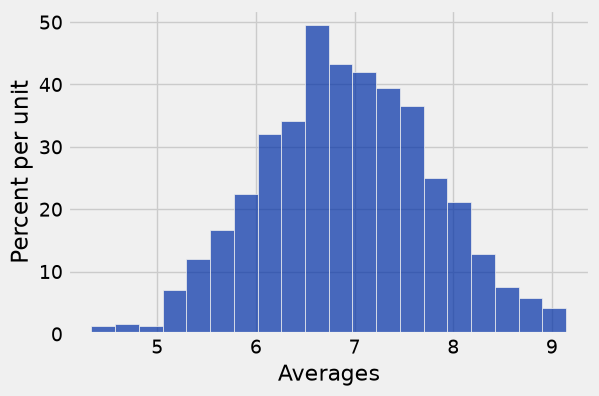

In [49]:
Table().with_column('Averages', simulated_averages).hist(0, bins=20)

In [50]:
np.count_nonzero(simulated_averages >= 9.61905) / len(simulated_averages)

0.0

In [51]:
# Conclusion: we reject the null hypothesis

---

# Titanic

In [52]:
titanic = Table.read_table('data/titanic.csv').where('Age', are.above_or_equal_to(0))
titanic

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S


In [53]:
# pretend we only have a size 100 sample and that's it
sample = titanic.sample(100, with_replacement=False)

In [54]:
sample.column('Age').mean()

30.8142

In [55]:
# generate a bootstrap sample from our original sample and give back the avg. age
def one_bootstrap_average():
    resample = sample.sample() # by default, .sample() means same size & with_replacement=True
    return resample.column('Age').mean()

In [56]:
one_bootstrap_average()

31.403400000000001

In [57]:
# Generate averages from 5000 bootstrap samples
repetitions = 5000
bootstrap_means = make_array()
for i in np.arange(repetitions):
    bootstrap_means = np.append(bootstrap_means, one_bootstrap_average())

In [58]:
bootstrap_means

array([ 31.26  ,  28.1742,  31.555 , ...,  30.515 ,  30.3392,  28.69  ])

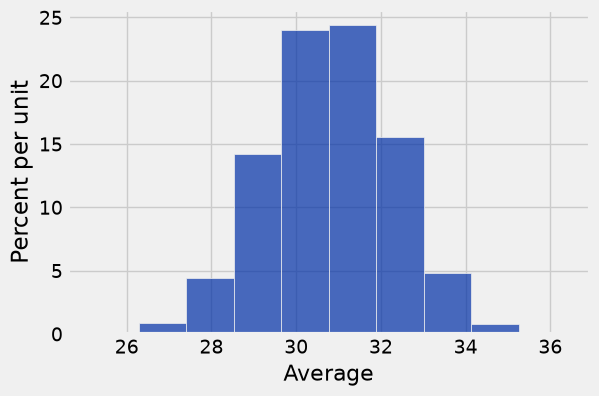

In [59]:
Table().with_column('Average', bootstrap_means).hist()

In [60]:
# Get a 95% confidence interval for the average age
percentile(2.5, bootstrap_means), percentile(97.5, bootstrap_means)

(27.923400000000001, 33.6342)

In [61]:
# Actual average age for every passenger
titanic.column('Age').mean()

29.69911764705882

# Father & Son

In [62]:
sons_heights = Table.read_table('data/sons_heights.csv').select('father', 'son')
sons_heights

father,son
78.5,73.2
75.5,73.5
75,71
75,70.5
75,72
74,76.5
74,74
73,71
73,68
73,71


In [63]:
def standard_units(arr):
    ''' Converts an array to standard units (a.k.a. z-scores) '''
    return (arr - np.mean(arr)) / np.std(arr)

def correlation(t, x, y):
    ''' Computes correlation coefficient r: t is a table, and x & y are column names '''
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.average(x_standard * y_standard)

def slope(t, x, y):
    """ Computes the slope of the regression line, like correlation above """
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

def intercept(t, x, y):
    """ Computes the intercept of the regression line, like slope above """
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

def fitted_values(t, x, y):
    """Return an array of the regression estimates (predictions) at all the x values"""
    m = slope(t, x, y)
    b = intercept(t, x, y)
    return m*t.column(x) + b

0.50072475554943707

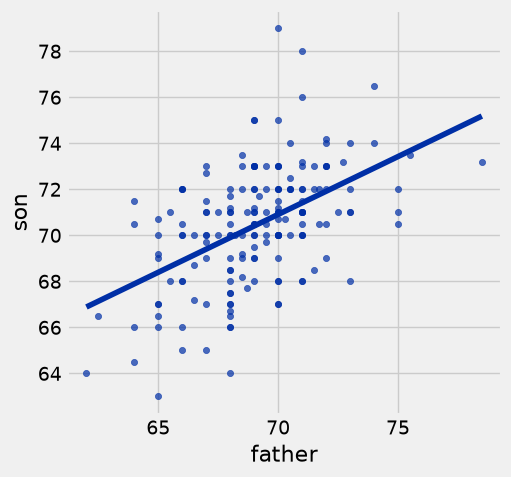

In [64]:
sons_heights.scatter('father', 'son', fit_line=True)
correlation(sons_heights, 'father', 'son')

In [65]:
sons_heights

father,son
78.5,73.2
75.5,73.5
75,71
75,70.5
75,72
74,76.5
74,74
73,71
73,68
73,71


In [66]:
# could use fitted_values, but this is more educational
m = slope(sons_heights, 'father', 'son')
b = intercept(sons_heights, 'father', 'son')
predictions = m*sons_heights.column('father') + b
heights_with_predictions = sons_heights.with_column('predicted son height', predictions)
heights_with_predictions

father,son,predicted son height
78.5,73.2,75.1815
75.5,73.5,73.6732
75,71,73.4218
75,70.5,73.4218
75,72,73.4218
74,76.5,72.919
74,74,72.919
73,71,72.4162
73,68,72.4162
73,71,72.4162


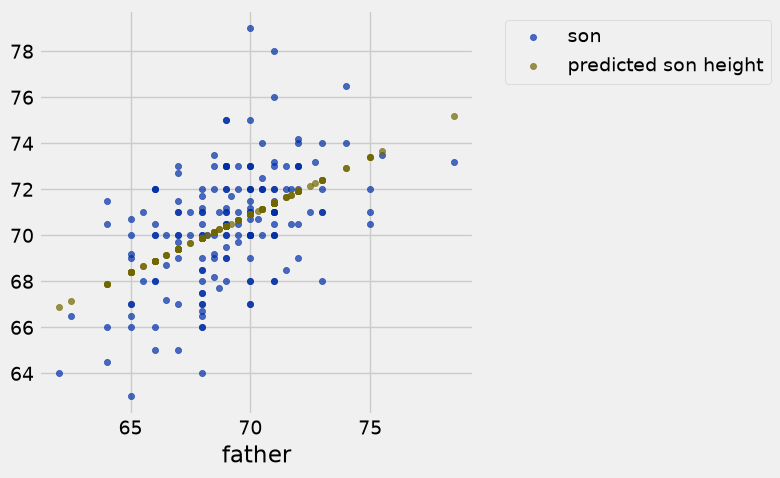

In [67]:
heights_with_predictions.scatter('father')

In [68]:
errors = heights_with_predictions.column('son') - heights_with_predictions.column('predicted son height')
heights_with_predictions.with_column('errors', errors)

father,son,predicted son height,errors
78.5,73.2,75.1815,-1.98154
75.5,73.5,73.6732,-0.173169
75,71,73.4218,-2.42177
75,70.5,73.4218,-2.92177
75,72,73.4218,-1.42177
74,76.5,72.919,3.58102
74,74,72.919,1.08102
73,71,72.4162,-1.41619
73,68,72.4162,-4.41619
73,71,72.4162,-1.41619


In [69]:
mse = np.mean(errors ** 2)
rmse = mse ** 0.5
rmse

2.2072170474409565

In [70]:
# regression estimates for slope & intercept
m, b

(0.50279044119141691, 35.712490894054319)

In [71]:
def rmse_son_height(m, b):
    x = sons_heights.column('father')
    y = sons_heights.column('son')
    predictions = m*x + b
    errors = y - predictions
    return np.mean(errors ** 2) ** 0.5

In [72]:
minimize(rmse_son_height, smooth=True)

array([  0.50278486,  35.71287682])

In [73]:
repetitions = 2500

# create 2500 bootstrap samples, find the slopes, and save them all
slopes = make_array()
for i in np.arange(repetitions):
    bootstrap_sample = sons_heights.sample()
    bootstrap_slope = slope(bootstrap_sample, 'father', 'son')
    slopes = np.append(slopes, bootstrap_slope)

In [74]:
# find the endpoints of the 95% confidence interval for the true slope
left = percentile(2.5, slopes)
right = percentile(97.5, slopes)

left, right

(0.37384020565309911, 0.64085208899828916)

# Classification

In [75]:
patients = Table.read_table('data/breast-cancer.csv').drop('ID')
patients.sample(10)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
6,6,6,5,4,10,7,6,2,1
5,3,6,1,2,1,1,1,1,0
2,1,1,1,2,1,3,1,1,0
7,5,10,10,10,10,4,10,3,1
5,3,1,1,2,1,1,1,1,0
1,1,1,1,2,1,1,1,1,0
7,8,7,6,4,3,8,8,4,1
1,1,1,1,2,1,1,1,1,0
10,5,8,10,3,10,5,1,3,1
4,3,3,1,2,1,3,3,1,0


In [76]:
patients.num_rows

683

In [77]:
683 / 2

341.5

In [78]:
shuffled_patients = patients.sample(683, with_replacement=False)
training_set = shuffled_patients.take(np.arange(342))
test_set = shuffled_patients.take(np.arange(342, 683))

In [79]:
def distance(point1, point2):
    return np.sum((point1 - point2) ** 2) ** 0.5

def all_distances(training, new_row):
    '''Returns an array of distances between each point in the training set
    and the new point (which is an row of attributes)'''
    attributes = training.drop('Class')

    # You can make functions inside other functions! They can use outer variables!
    def distance_from_new_row(row):
        return distance(np.array(new_row), np.array(row))
    
    return attributes.apply(distance_from_new_row)

def nearest(training, new_point, k):
    '''Returns a table of the k rows (with distances attached)
    having the smallest distances from the new_point'''
    distances_to_new_point = all_distances(training, new_point)
    with_dists = training.with_column('Distance', distances_to_new_point)
    sorted_by_distance = with_dists.sort('Distance')
    nearest_neighbors_table = sorted_by_distance.take(np.arange(k))
    return nearest_neighbors_table

def majority(nearest_neighbors_table):
    ones = nearest_neighbors_table.where('Class', are.equal_to(1)).num_rows
    zeros = nearest_neighbors_table.where('Class', are.equal_to(0)).num_rows
    
    if ones > zeros:
        return 1
    else:
        return 0

def knn(training, new_point, k):
    nearest_neighbors_table = nearest(training, new_point, k)
    return majority(nearest_neighbors_table)

def evaluate_accuracy(training, test, k):
    test_attributes = test.drop('Class')

    def classify_test_row(row):
        return knn(training, row, k)

    predicted_classes = test_attributes.apply(classify_test_row)
    return np.count_nonzero(predicted_classes == test.column('Class')) / test.num_rows

In [80]:
evaluate_accuracy(training_set, test_set, 5)

0.97947214076246336

In [81]:
# Remember: if the range of values for your columns are widely different from one another,
# (for example, one column ranges from 1-10 and another ranges from 1000-9999), then it's
# a good idea to get every column on an even playing field by converting them to standard units
# (a.k.a. z-scores). If you don't do that, you distance calculations will be biased.

In [82]:
distance(make_array(1, 2), make_array(3, 4))

2.8284271247461903

In [83]:
distance(make_array(1, 2), make_array(5, 4))

4.4721359549995796

In [84]:
distance(make_array(1, 2000), make_array(3, 4000))

2000.0009999997501

In [85]:
distance(make_array(1, 2000), make_array(5, 4000))  # the 3->5 didn't do anything at all :(

2000.0039999959999

In [86]:
patients

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
5,1,1,1,2,1,3,1,1,0
5,4,4,5,7,10,3,2,1,0
3,1,1,1,2,2,3,1,1,0
6,8,8,1,3,4,3,7,1,0
4,1,1,3,2,1,3,1,1,0
8,10,10,8,7,10,9,7,1,1
1,1,1,1,2,10,3,1,1,0
2,1,2,1,2,1,3,1,1,0
2,1,1,1,2,1,1,1,5,0
4,2,1,1,2,1,2,1,1,0


In [87]:
standard_units(patients.column(0))

array([ 0.19790469,  0.19790469, -0.51164337,  0.55267873, -0.15686934,
        1.26222679, -1.22119144, -0.8664174 , -0.8664174 , -0.15686934,
       -1.22119144, -0.8664174 ,  0.19790469, -1.22119144,  1.26222679,
        0.90745276, -0.15686934, -0.15686934,  1.97177486,  0.55267873,
        0.90745276,  1.97177486, -0.51164337, -1.22119144,  0.19790469,
       -0.51164337,  0.19790469, -0.8664174 , -1.22119144, -0.51164337,
       -0.8664174 ,  1.97177486, -0.8664174 , -0.51164337, -0.8664174 ,
        1.97177486,  0.55267873,  0.19790469, -0.8664174 ,  1.97177486,
        0.55267873,  0.19790469,  1.97177486, -1.22119144, -0.51164337,
       -1.22119144, -0.15686934,  0.90745276,  1.61700083,  0.19790469,
        1.97177486,  0.19790469,  1.97177486,  1.97177486,  1.26222679,
        1.26222679,  0.19790469,  1.61700083,  0.19790469, -1.22119144,
        1.61700083,  0.55267873, -1.22119144,  1.97177486, -0.15686934,
        0.19790469,  1.26222679, -1.22119144,  0.19790469,  0.55

# Bayes' Rule

In [88]:
(0.5 * 0.6) / (0.6 * 0.5 + 0.4 * 0.8)

0.4838709677419354